*This notebook is designed to tackle the classic MNIST dataset. It is a classic image classification problem with 70,000 small images of digits with their labels*

In [1]:
from sklearn.datasets import fetch_openml

mnist= fetch_openml("mnist_784", as_frame= False)

In [5]:
mnist["DESCR"]

"**Author**: Yann LeCun, Corinna Cortes, Christopher J.C. Burges  \n**Source**: [MNIST Website](http://yann.lecun.com/exdb/mnist/) - Date unknown  \n**Please cite**:  \n\nThe MNIST database of handwritten digits with 784 features, raw data available at: http://yann.lecun.com/exdb/mnist/. It can be split in a training set of the first 60,000 examples, and a test set of 10,000 examples  \n\nIt is a subset of a larger set available from NIST. The digits have been size-normalized and centered in a fixed-size image. It is a good database for people who want to try learning techniques and pattern recognition methods on real-world data while spending minimal efforts on preprocessing and formatting. The original black and white (bilevel) images from NIST were size normalized to fit in a 20x20 pixel box while preserving their aspect ratio. The resulting images contain grey levels as a result of the anti-aliasing technique used by the normalization algorithm. the images were centered in a 28x28 

In [3]:
mnist.categories

{'class': ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9']}

In [8]:
mnist.target_names

['class']

In [46]:
X, y = mnist.data, mnist.target
X[:3]

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], dtype=int64)

In [12]:
X.shape

(70000, 784)

In [47]:
y

array(['5', '0', '4', ..., '4', '5', '6'], dtype=object)

In [14]:
y.shape

(70000,)

*Let's checkout a sample image*

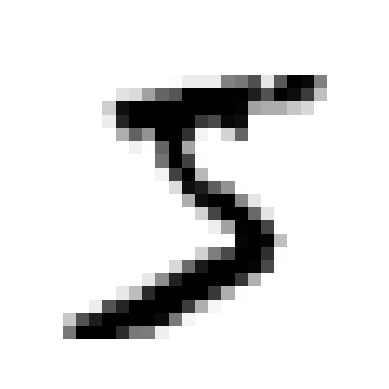

In [40]:
import matplotlib.pyplot as plt

def plot_digit(image_data): 
    image= image_data.reshape(28,28)
    plt.imshow(image, cmap= "binary")
    plt.axis("off")

some_digit= X[0] 
plot_digit(some_digit)
plt.show()

In [17]:
some_digit= X[0].reshape(28,28)

In [39]:
some_digit

array([[  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   3,
         18,  18,  18, 126, 136, 175,  26, 166, 255, 247, 127,   0,   0,
          0,   0],
       [  

In [37]:
import numpy as np

x, y = np.meshgrid(np.arange(28), np.arange(28))
27  -y.flatten()

array([27, 27, 27, 27, 27, 27, 27, 27, 27, 27, 27, 27, 27, 27, 27, 27, 27,
       27, 27, 27, 27, 27, 27, 27, 27, 27, 27, 27, 26, 26, 26, 26, 26, 26,
       26, 26, 26, 26, 26, 26, 26, 26, 26, 26, 26, 26, 26, 26, 26, 26, 26,
       26, 26, 26, 26, 26, 25, 25, 25, 25, 25, 25, 25, 25, 25, 25, 25, 25,
       25, 25, 25, 25, 25, 25, 25, 25, 25, 25, 25, 25, 25, 25, 25, 25, 24,
       24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24,
       24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 23, 23, 23, 23, 23, 23, 23,
       23, 23, 23, 23, 23, 23, 23, 23, 23, 23, 23, 23, 23, 23, 23, 23, 23,
       23, 23, 23, 23, 22, 22, 22, 22, 22, 22, 22, 22, 22, 22, 22, 22, 22,
       22, 22, 22, 22, 22, 22, 22, 22, 22, 22, 22, 22, 22, 22, 22, 21, 21,
       21, 21, 21, 21, 21, 21, 21, 21, 21, 21, 21, 21, 21, 21, 21, 21, 21,
       21, 21, 21, 21, 21, 21, 21, 21, 21, 20, 20, 20, 20, 20, 20, 20, 20,
       20, 20, 20, 20, 20, 20, 20, 20, 20, 20, 20, 20, 20, 20, 20, 20, 20,
       20, 20, 20, 19, 19

In [41]:
### .imshow() under the hood

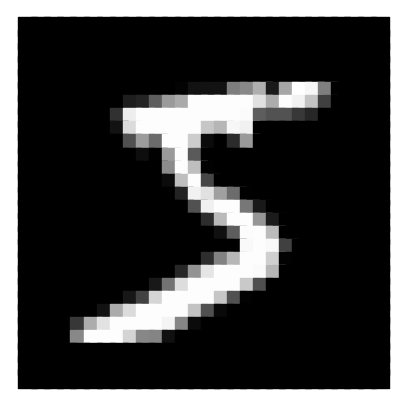

In [45]:
xx, yy = np.meshgrid(np.arange(28), np.arange(28))
plt.figure(figsize=(5,5))

plt.scatter(
    xx.flatten(),
    27 - yy.flatten(),          # Flip vertically (last pixel = 784 is bottom right (27,0) not top right (27,27)
    c=some_digit.flatten(),
    cmap="grey",
    marker="s",
    s=180
)

plt.axis("equal")
plt.axis("off")
plt.show()

In [48]:
y[0]

'5'

*Clearly a 5*

According to the DESCR, the MNIST dataset is already split into a training (first 60k instances) and test set (final 10k)

In [49]:
X_train, X_test, y_train, y_test= X[:60000], X[60000:], y[:60000], y[60000: ]

### Binary Classifier

Let's just go with a **5** or **non 5** classifier first

In [50]:
y_train_5 = (y_train == '5')
y_test_5  = (y_test == '5')

*Model 1-> **SGD Classifier***

In [51]:
from sklearn.linear_model import SGDClassifier

sgd_clf = SGDClassifier(random_state=42) 
sgd_clf.fit(X_train, y_train_5)

SGDClassifier(random_state=42)

In [53]:
sgd_clf.predict([some_digit])

array([ True])

In [55]:
from sklearn.model_selection import cross_val_score
cross_val_score(sgd_clf, X_train, y_train_5, cv= 3, scoring = "accuracy")

array([0.95035, 0.96035, 0.9604 ])

*95% accuracy on the first shot, that's amazing innit???*

*Well.. check this out*

In [59]:
from sklearn.dummy import DummyClassifier

dummy_clf = DummyClassifier() ## Predicts the most frequent class in training
dummy_clf.fit(X_train, y_train_5)
print(any(dummy_clf.predict(X_train)))

False


In [60]:
cross_val_score(dummy_clf, X_train, y_train_5, cv= 3, scoring ="accuracy")

array([0.90965, 0.90965, 0.90965])

*well... that should have been obvious.. only 10% of the images should actually be 5s.. so if you just go non_5s on all cases.. you're getting a 90% accuracy*

*suddenly, the 95% accuracy, does'nt look that great..*

### Accuracy Metrics

In [62]:
from sklearn.model_selection import cross_val_predict

y_train_pred= cross_val_predict(sgd_clf, X_train, y_train_5, cv= 3) ## All out of sample predicitons

In [63]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_train_5, y_train_pred)
cm

array([[53892,   687],
       [ 1891,  3530]], dtype=int64)

*yeah well, more than one third of our 5s are getting falsely classified as non 5s.. can't go ahead we that, can we..*

**Precision**-> Accuracy of the +ve predictions.. (how precise are we?)  
**Recall**   -> Ratio of +ve instances actually classified correctly   

In [64]:
from sklearn.metrics import precision_score, recall_score

precision_score(y_train_5, y_train_pred)

0.8370879772350012

In [65]:
recall_score(y_train_5, y_train_pred)

0.6511713705958311

*Only **65%** of the 5s are actually being classified as a 5...Model does'nt look as shiny now.. huh*

In [66]:
## Understanding decison_scores and setting thresholds

In [67]:
y_scores= cross_val_predict(sgd_clf, X_train, y_train_5, cv= 3, method="decision_function")

In [76]:
y_train_5[:11]

array([ True, False, False, False, False, False, False, False, False,
       False, False])

In [77]:
y_scores[:11]

array([  1200.93051237, -26883.79202424, -33072.03475406, -15919.5480689 ,
       -20003.53970191, -16652.87731528, -14276.86944263, -23328.13728948,
        -5172.79611432, -13873.5025381 , -22112.989794  ])

*The default threshold used by SGDClassifier is set to **0**. A decsion score over that, leads to +ve prediction*

In [79]:
from sklearn.metrics import precision_recall_curve

precisions, recalls, thresholds = precision_recall_curve(y_train_5, y_scores)

In [82]:
precisions

array([0.09035   , 0.09035151, 0.09035301, ..., 1.        , 1.        ,
       1.        ])

In [83]:
recalls

array([1.00000000e+00, 1.00000000e+00, 1.00000000e+00, ...,
       3.68935621e-04, 1.84467810e-04, 0.00000000e+00])

In [95]:
thresholds

array([             inf,   49441.43765905,   36801.60697028, ...,
       -105763.22240074, -106527.45300471, -146348.56726174])

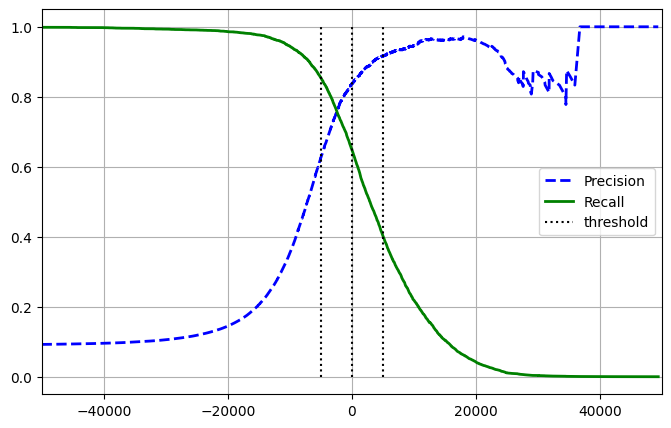

In [87]:
plt.figure(figsize= (8,5))

plt.plot(thresholds, precisions[:-1], "b--", label= "Precision", linewidth=2)
plt.plot(thresholds, recalls[:-1], "g-", label= "Recall", linewidth=2)
plt.vlines([-5000, 0, 5000], 0, 1.0, "k", "dotted", label= "threshold")

plt.legend()
plt.xlim(-50000, 50000)
plt.grid()

plt.show()

*So ideally, it's between a threshold of -5k and 0, depending on what metric we value more for this case*

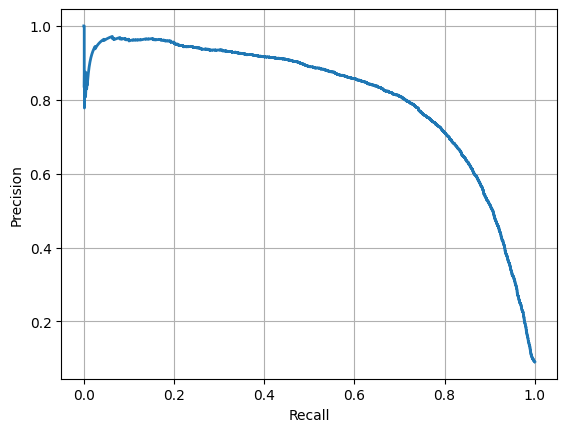

In [89]:
plt.plot(recalls, precisions, linewidth= 2, label = "Precision/Recall Curve")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.grid()

plt.show()

In [90]:
idx_for_90_precision = (precisions>= 0.90).argmax()
threshold_for_90_precision = thresholds[idx_for_90_precision]
threshold_for_90_precision

3370.0194991439557

In [91]:
y_train_pred_90 = (y_scores>= threshold_for_90_precision)

In [92]:
precision_score(y_train_5, y_train_pred_90)

0.9000345901072293

In [93]:
recall_score(y_train_5, y_train_pred_90)

0.4799852425751706

In [94]:
from sklearn.metrics import roc_curve

fpr, tpr, thresholds= roc_curve(y_train_5, y_scores)

In [96]:
thresholds

array([             inf,   49441.43765905,   36801.60697028, ...,
       -105763.22240074, -106527.45300471, -146348.56726174])

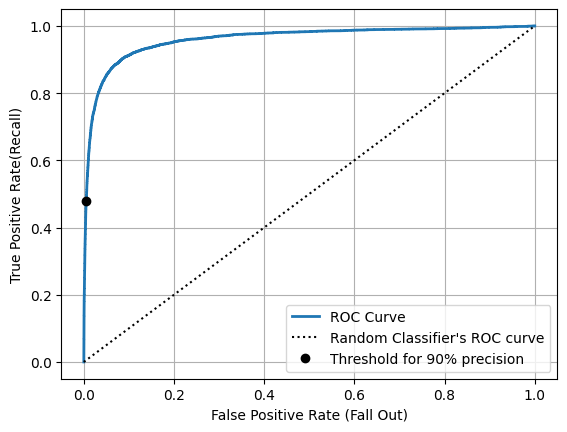

In [98]:
idx_for_threshold_at_90 = (thresholds <= threshold_for_90_precision).argmax()
tpr_90, fpr_90 = tpr[idx_for_threshold_at_90], fpr[idx_for_threshold_at_90]

plt.plot(fpr, tpr, linewidth= 2, label = "ROC Curve")
plt.plot([0,1], [0,1], "k:", label= "Random Classifier's ROC curve")
plt.plot([fpr_90], [tpr_90], "ko", label= "Threshold for 90% precision")


plt.xlabel("False Positive Rate (Fall Out)")
plt.ylabel("True Positive Rate(Recall)")
plt.legend()
plt.grid()

plt.show()

In [99]:
from sklearn.metrics import roc_auc_score ## Gotta be maximising this.. area under roc curve
roc_auc_score(y_train_5, y_scores)

0.9604938554008616

In [100]:
from sklearn.ensemble import RandomForestClassifier

forest_clf= RandomForestClassifier(random_state=42)

In [101]:
y_probas_forest= cross_val_predict(forest_clf, X_train, y_train_5, cv= 3, method = "predict_proba")

In [102]:
y_probas_forest[:5]

array([[0.11, 0.89],
       [0.99, 0.01],
       [0.96, 0.04],
       [1.  , 0.  ],
       [0.99, 0.01]])

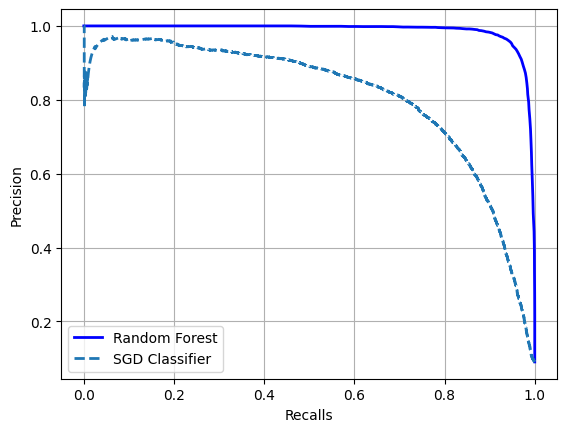

In [103]:
y_scores_forest = y_probas_forest[:, 1] ## the second col has probabilities for +ve prediction
precisions_forest, recalls_forest, thresholds_forest= precision_recall_curve(y_train_5, y_scores_forest)

plt.plot(recalls_forest, precisions_forest, "b-", linewidth = 2, label = "Random Forest")
plt.plot(recalls, precisions, "--", linewidth=  2, label ="SGD Classifier")


plt.xlabel("Recalls")
plt.ylabel("Precision")
plt.legend()
plt.grid()
plt.show()

Much better, clearly

In [105]:
from sklearn.metrics import f1_score

y_train_pred_forest= y_probas_forest[:,1] >= 0.5
f1_score(y_train_5, y_train_pred_forest)

0.9274509803921569

In [106]:
roc_auc_score(y_train_5, y_scores_forest)

0.9983436731328145